# New York Taxi Trip Prediction Project

Predicting New York City taxi trip durations using NYC TLC ride data to optimize travel time estimation with a competitive RMSLE score.

<img src='https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcT67bX_YnbyCnPisNZgJvWxpz1L5P03C2pT1Gie02PAmQ&s=10' width='750'>

In [1]:
# Libraries
import pandas as pd
pd.set_option('display.max_columns', 55)  
import warnings
warnings.filterwarnings('ignore')  
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

# EDA

In [2]:
df1=pd.read_csv('train.csv')

In [3]:
df2=pd.read_csv('test.csv')

In [4]:
df1.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [5]:
df1.tail()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
1458639,id2376096,2,2016-04-08 13:31:04,2016-04-08 13:44:02,4,-73.982201,40.745522,-73.994911,40.740170,N,778
1458640,id1049543,1,2016-01-10 07:35:15,2016-01-10 07:46:10,1,-74.000946,40.747379,-73.970184,40.796547,N,655
1458641,id2304944,2,2016-04-22 06:57:41,2016-04-22 07:10:25,1,-73.959129,40.768799,-74.004433,40.707371,N,764
1458642,id2714485,1,2016-01-05 15:56:26,2016-01-05 16:02:39,1,-73.982079,40.749062,-73.974632,40.757107,N,373
1458643,id1209952,1,2016-04-05 14:44:25,2016-04-05 14:47:43,1,-73.979538,40.781750,-73.972809,40.790585,N,198


In [6]:
df1.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


In [7]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [8]:
df1.shape

(1458644, 11)

In [9]:
df1.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [10]:
df1.corr(numeric_only=True) 

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
vendor_id,1.000000,0.287415,0.007820,0.001742,0.001528,0.004496,0.020304
passenger_count,0.287415,1.000000,0.002169,-0.005125,-0.000343,-0.002762,0.008471
pickup_longitude,0.007820,0.002169,1.000000,0.022568,0.783582,0.100190,0.026542
pickup_latitude,0.001742,-0.005125,0.022568,1.000000,0.114884,0.494038,-0.029204
dropoff_longitude,0.001528,-0.000343,0.783582,0.114884,1.000000,0.124873,0.014678
dropoff_latitude,0.004496,-0.002762,0.100190,0.494038,0.124873,1.000000,-0.020677
trip_duration,0.020304,0.008471,0.026542,-0.029204,0.014678,-0.020677,1.000000


In [11]:
sns.set_style("whitegrid")

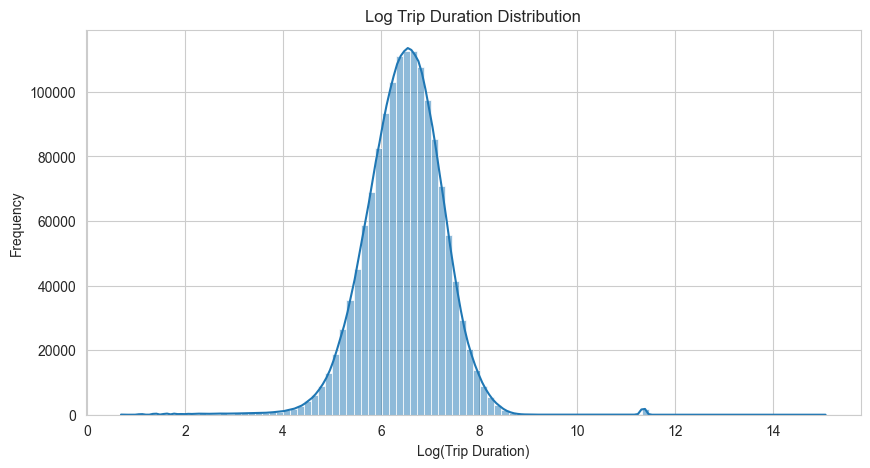

In [12]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df1,
    x=np.log1p(df1["trip_duration"]),
    bins=100,
    kde=True
)

plt.title("Log Trip Duration Distribution")
plt.xlabel("Log(Trip Duration)")
plt.ylabel("Frequency")

plt.show()

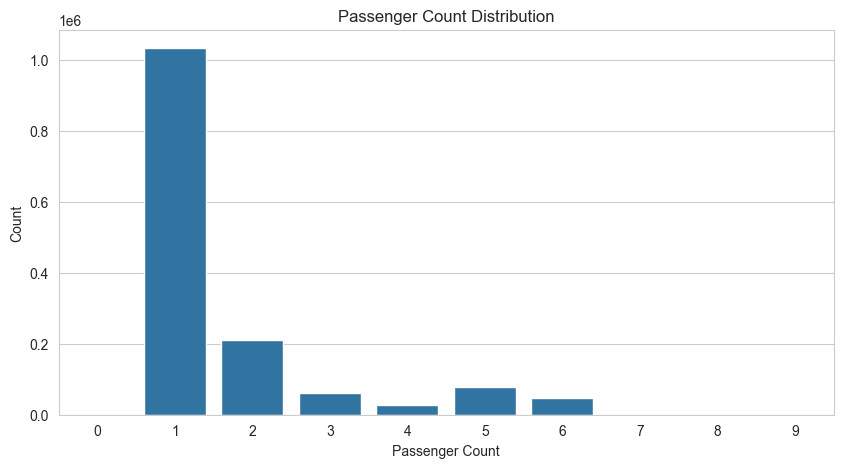

In [13]:
plt.figure(figsize=(10, 5))
sns.countplot(    data=df1,    x="passenger_count")
plt.title("Passenger Count Distribution")
plt.xlabel("Passenger Count")
plt.ylabel("Count")
plt.show()

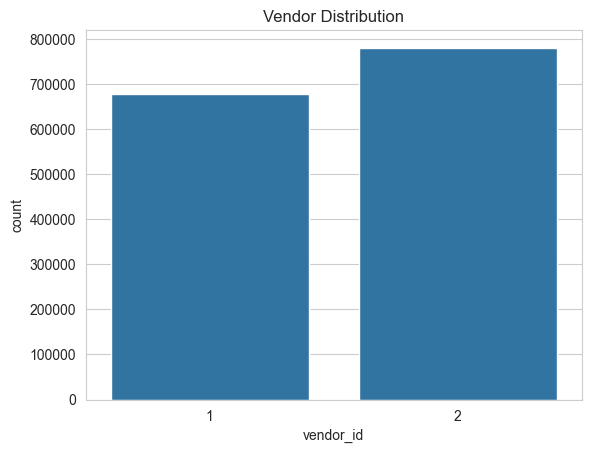

In [14]:
plt.figure()
sns.countplot(x="vendor_id", data=df1)
plt.title("Vendor Distribution")
plt.show()

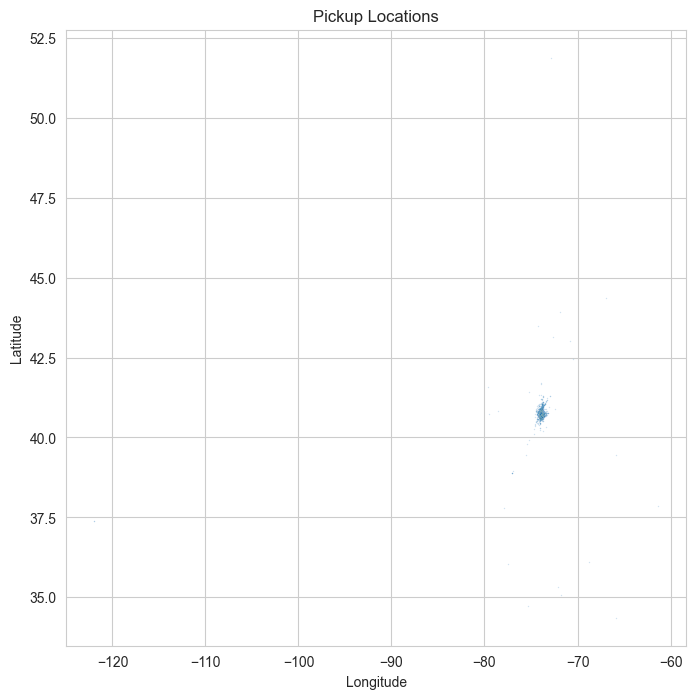

In [15]:
plt.figure(figsize=(8, 8))
sns.scatterplot(data=df1, x="pickup_longitude", y="pickup_latitude",  s=1,  alpha=0.2)
plt.title("Pickup Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

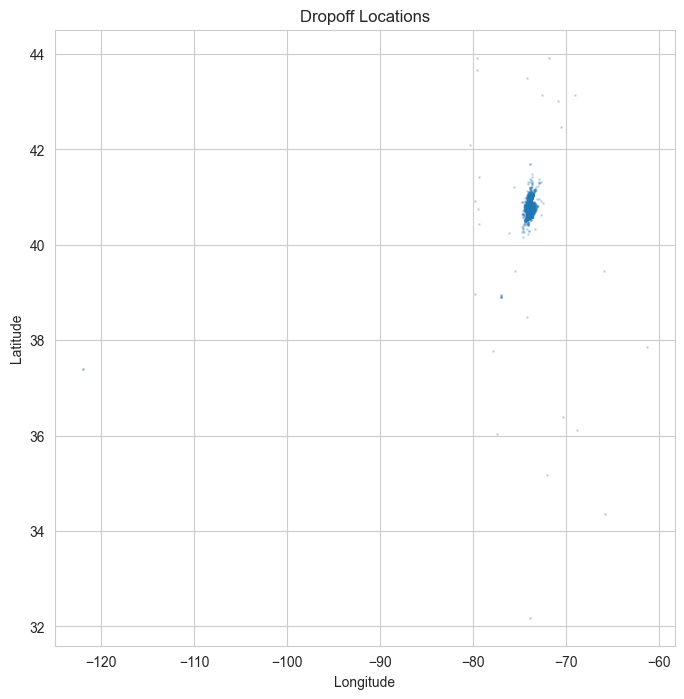

In [16]:
plt.figure(figsize=(8,8))
plt.scatter(df1["dropoff_longitude"], df1["dropoff_latitude"], 
            s=1, alpha=0.2)
plt.title("Dropoff Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [17]:
df1["pickup_datetime"] = pd.to_datetime(df1["pickup_datetime"])
df1["pickup_hour"] = df1["pickup_datetime"].dt.hour

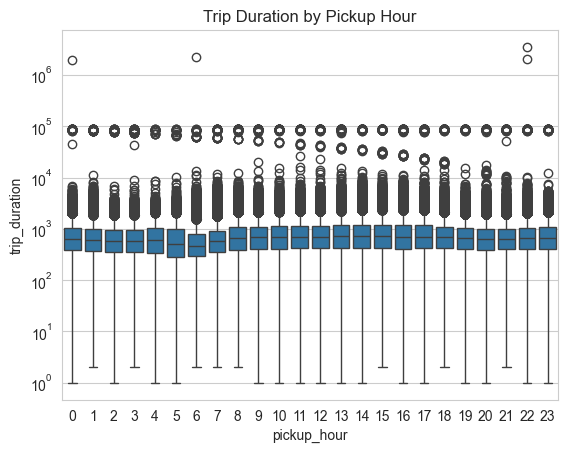

In [18]:
plt.figure()
sns.boxplot(x="pickup_hour", y="trip_duration", data=df1)
plt.yscale("log")
plt.title("Trip Duration by Pickup Hour")
plt.show()

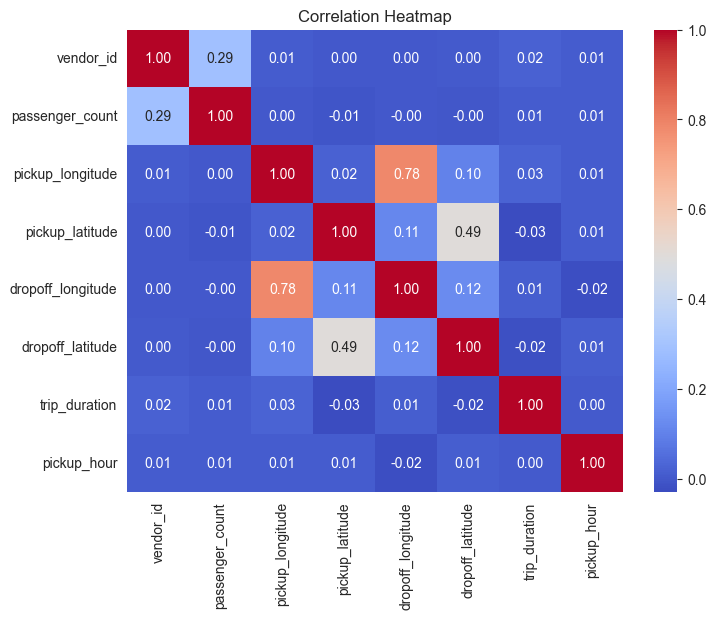

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(df1.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [20]:
print("Before:", df1.shape)

df1 = df1.query("60 <= trip_duration <= 7200")

print("After:", df1.shape)

Before: (1458644, 12)
After: (1447796, 12)


In [21]:
df1 = df1[
    (df1["pickup_longitude"].between(-74.03, -73.75)) &
    (df1["pickup_latitude"].between(40.63, 40.85)) &
    (df1["dropoff_longitude"].between(-74.03, -73.75)) &
    (df1["dropoff_latitude"].between(40.63, 40.85))
]

In [22]:
df1 = df1[(df1["passenger_count"] > 0) & (df1["passenger_count"] <= 6)]

In [23]:
from math import asin, cos, radians, sin, sqrt

import numpy as np


def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371  # km

    return c * r


df1["distance_km"] = haversine(
    df1["pickup_longitude"],
    df1["pickup_latitude"],
    df1["dropoff_longitude"],
    df1["dropoff_latitude"],
)

In [24]:
df1 = df1[(df1["distance_km"] > 0.1) & (df1["distance_km"] < 50)]

In [25]:
Q1 = df1["trip_duration"].quantile(0.25)
Q3 = df1["trip_duration"].quantile(0.75)
IQR = Q3 - Q1

df1 = df1[
    (df1["trip_duration"] >= Q1 - 1.5*IQR) &
    (df1["trip_duration"] <= Q3 + 1.5*IQR)
]

In [26]:
print(df1.shape)
df1["trip_duration"].describe()

(1295086, 13)


count    1.295086e+06
mean     7.380404e+02
std      4.405183e+02
min      6.000000e+01
25%      3.950000e+02
50%      6.400000e+02
75%      9.950000e+02
max      2.074000e+03
Name: trip_duration, dtype: float64

### Feature Engineering

In [27]:
df1["is_train"] = 1
df2["is_train"] = 0

df = pd.concat([df1, df2], ignore_index=True)

In [28]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])

df["pickup_hour"] = df["pickup_datetime"].dt.hour
df["pickup_day"] = df["pickup_datetime"].dt.day
df["pickup_weekday"] = df["pickup_datetime"].dt.weekday
df["pickup_month"] = df["pickup_datetime"].dt.month
df["is_weekend"] = df["pickup_weekday"].isin([5,6]).astype(int)

In [29]:
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371
    return c * r

df["distance_km"] = haversine(
    df["pickup_longitude"],
    df["pickup_latitude"],
    df["dropoff_longitude"],
    df["dropoff_latitude"]
)

In [30]:
df["manhattan_km"] = (
    haversine(df["pickup_longitude"], df["pickup_latitude"],
              df["dropoff_longitude"], df["pickup_latitude"]) +
    haversine(df["pickup_longitude"], df["pickup_latitude"],
              df["pickup_longitude"], df["dropoff_latitude"])
)

In [31]:
def bearing(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1)*np.sin(lat2) - np.sin(lat1)*np.cos(lat2)*np.cos(dlon)
    return np.degrees(np.arctan2(x, y))

df["direction"] = bearing(
    df["pickup_longitude"],
    df["pickup_latitude"],
    df["dropoff_longitude"],
    df["dropoff_latitude"]
)

In [32]:
df["vendor_id"] = df["vendor_id"].astype("category")

In [33]:
df["store_and_fwd_flag"] = (df["store_and_fwd_flag"] == "Y").astype(int)

In [34]:
drop_cols = ["id", "pickup_datetime", "dropoff_datetime"]
df = df.drop(columns=drop_cols)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1920220 entries, 0 to 1920219
Data columns (total 17 columns):
 #   Column              Dtype   
---  ------              -----   
 0   vendor_id           category
 1   passenger_count     int64   
 2   pickup_longitude    float64 
 3   pickup_latitude     float64 
 4   dropoff_longitude   float64 
 5   dropoff_latitude    float64 
 6   store_and_fwd_flag  int64   
 7   trip_duration       float64 
 8   pickup_hour         int32   
 9   distance_km         float64 
 10  is_train            int64   
 11  pickup_day          int32   
 12  pickup_weekday      int32   
 13  pickup_month        int32   
 14  is_weekend          int64   
 15  manhattan_km        float64 
 16  direction           float64 
dtypes: category(1), float64(8), int32(4), int64(4)
memory usage: 206.9 MB


### Modeling

In [36]:
train_df = df[df["is_train"] == 1].drop(columns=["is_train"])
test_df = df[df["is_train"] == 0].drop(columns=["is_train", "trip_duration"])

In [37]:
x = train_df.drop(columns=["trip_duration"])
y = np.log1p(train_df["trip_duration"])

In [38]:
x = pd.get_dummies(x, drop_first=True)

In [43]:
import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge, SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor


def algo_test(x, y):
    # Feature Scaling
    scaler = MinMaxScaler()
    x_scaled = scaler.fit_transform(x)

    # Train/Test Split
    x_train, x_test, y_train, y_test = train_test_split(
        x_scaled, y, test_size=0.20, random_state=42
    )

    # Models
    l = LinearRegression()
    r = Ridge()
    las = Lasso()
    e = ElasticNet()
    sgd = SGDRegressor()
    ETR = ExtraTreesRegressor()
    GBR = GradientBoostingRegressor()
    kn = KNeighborsRegressor()
    dt = DecisionTreeRegressor()
    xgb = XGBRegressor()

    algos = [l, r, las, e, sgd, ETR, GBR, kn, dt, xgb]
    algo_names = [
        "Linear",
        "Ridge",
        "Lasso",
        "ElasticNet",
        "SGD",
        "Extra Tree",
        "Gradient Boosting",
        "KNeighbors",
        "Decision Tree",
        "XGB",
    ]

    r_squared = []
    rmse = []
    mae = []

    for algo in algos:
        p = algo.fit(x_train, y_train).predict(x_test)
        r_squared.append(r2_score(y_test, p))
        rmse.append(mean_squared_error(y_test, p) ** 0.5)
        mae.append(mean_absolute_error(y_test, p))

    result = pd.DataFrame(
        {"R_Squared": r_squared, "RMSE": rmse, "MAE": mae}, index=algo_names
    )

    return result.sort_values(by="RMSE")

In [44]:
algo_test(x,y)

,R_Squared,RMSE,MAE
XGB,7.905861e-01,0.299199,0.223454
Extra Tree,7.861131e-01,0.302377,0.225521
Gradient Boosting,7.264605e-01,0.341953,0.261270
Decision Tree,5.608453e-01,0.433277,0.322961
KNeighbors,5.509477e-01,0.438132,0.333010
Ridge,4.032647e-01,0.505066,0.394148
Linear,4.032641e-01,0.505066,0.394144
SGD,4.023924e-01,0.505435,0.395265
Lasso,-5.216282e-07,0.653818,0.530220
ElasticNet,-5.216282e-07,0.653818,0.530220


### Feature Importance

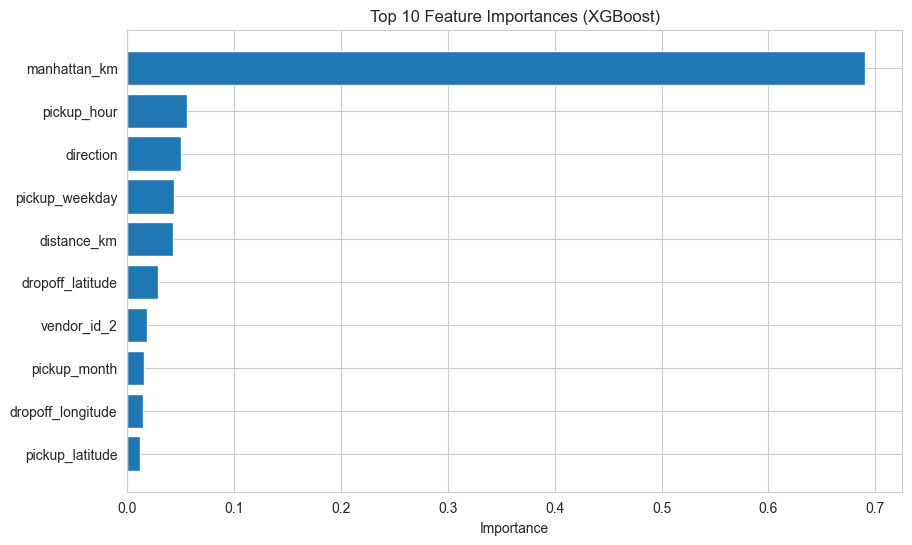

In [47]:
import matplotlib.pyplot as plt
import pandas as pd
from xgboost import XGBRegressor

# 1. Train the best model and assign it to 'model'
model = XGBRegressor()
model.fit(x, y)

# 2. Extract feature importances
importance = model.feature_importances_
feature_names = x.columns

feat_imp = (
    pd.DataFrame({"Feature": feature_names, "Importance": importance})
    .sort_values("Importance", ascending=False)
    .head(10)
)

# 3. Plot top 10 features
plt.figure(figsize=(10, 6))
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.show()

In [49]:
import joblib

joblib.dump(model, "nyc_taxi_xgb_model.pkl")

['nyc_taxi_xgb_model.pkl']

XGBoost achieved the highest predictive power with an R² of 0.7906, identifying trip distance and location coordinates as the primary drivers of NYC taxi duration.